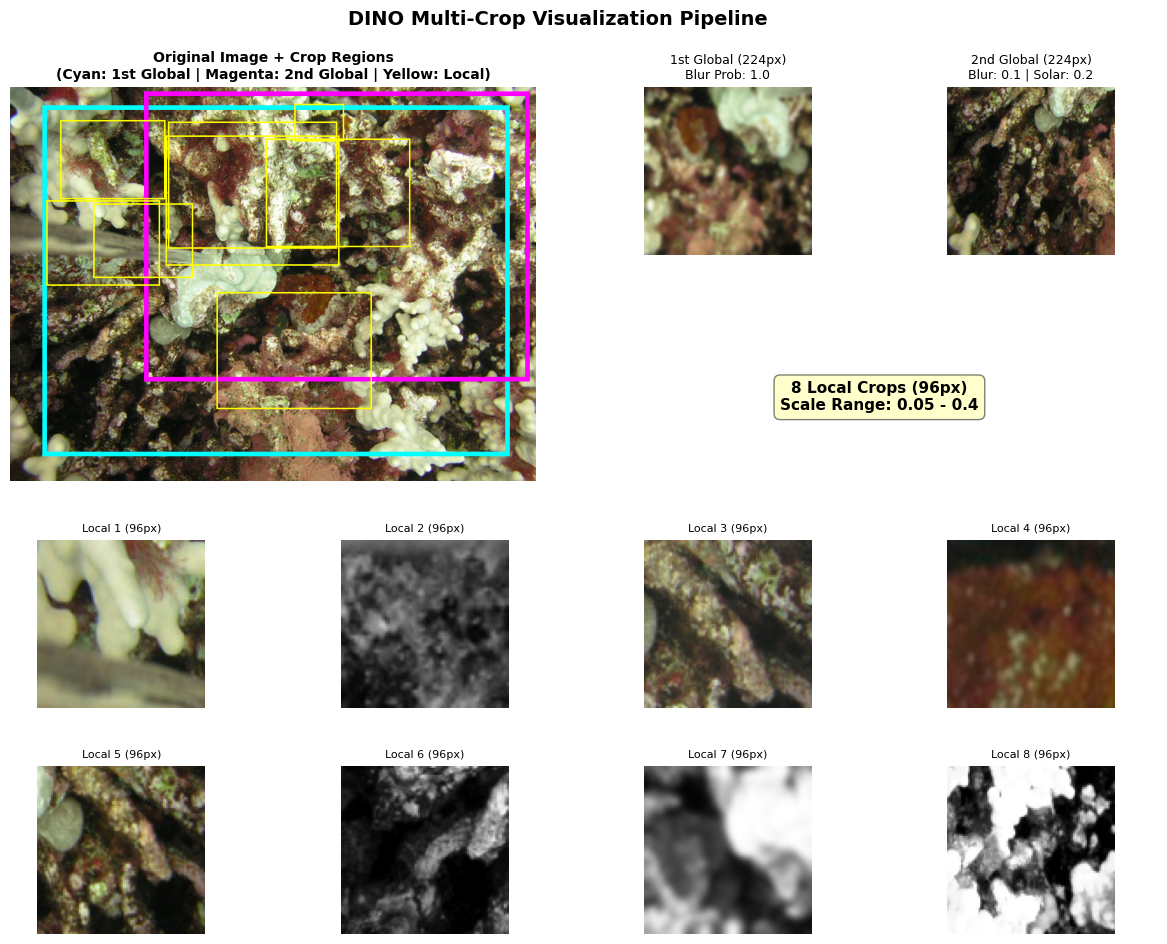

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageOps, ImageEnhance, ImageFilter

# 1. Configuration dictionaries provided by you
configs = {
    "1st Global": {
        "crop_size": 224, "crop_min": 0.4, "crop_max": 1.0,
        "color_jitter": {"prob": 0.8, "brightness": 0.4, "contrast": 0.4, "saturation": 0.2, "hue": 0.1},
        "grayscale": 0.2, "gaussian_blur": 1.0, "solarization": 0.0, "horizontal_flip": 0.5
    },
    "2nd Global": {
        "crop_size": 224, "crop_min": 0.4, "crop_max": 1.0,
        "color_jitter": {"prob": 0.8, "brightness": 0.4, "contrast": 0.4, "saturation": 0.2, "hue": 0.1},
        "grayscale": 0.2, "gaussian_blur": 0.1, "solarization": 0.2, "horizontal_flip": 0.5
    },
    "Local": {
        "crop_size": 96, "crop_min": 0.05, "crop_max": 0.4,
        "color_jitter": {"prob": 0.8, "brightness": 0.4, "contrast": 0.4, "saturation": 0.2, "hue": 0.1},
        "grayscale": 0.2, "gaussian_blur": 0.5, "solarization": 0.0, "horizontal_flip": 0.5
    }
}

def apply_transforms(img, config):
    """Applies your multi-crop configuration sequentially to a PIL image copy."""
    img = img.copy()
    
    # Horizontal Flip
    if random.random() < config["horizontal_flip"]:
        img = ImageOps.mirror(img)
        
    # Random Resized Crop (RRC)
    w, h = img.size
    scale = random.uniform(config["crop_min"], config["crop_max"])
    crop_w, crop_h = int(w * scale), int(h * scale)
    left = random.randint(0, max(0, w - crop_w))
    top = random.randint(0, max(0, h - crop_h))
    
    img = img.crop((left, top, left + crop_w, top + crop_h))
    img = img.resize((config["crop_size"], config["crop_size"]), Image.Resampling.BILINEAR)
    
    # Color Jitter
    cj = config["color_jitter"]
    if random.random() < cj["prob"]:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(max(0, 1 - cj["brightness"]), 1 + cj["brightness"]))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(max(0, 1 - cj["contrast"]), 1 + cj["contrast"]))
        img = ImageEnhance.Color(img).enhance(random.uniform(max(0, 1 - cj["saturation"]), 1 + cj["saturation"]))
        
    # Grayscale
    if random.random() < config["grayscale"]:
        img = ImageOps.grayscale(img).convert("RGB")
        
    # Gaussian Blur
    if random.random() < config["gaussian_blur"]:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 2.0)))
        
    # Solarization
    if random.random() < config["solarization"]:
        img = ImageOps.solarize(img, threshold=128)
        
    return img

def get_crop_box(img, config):
    """Calculates the bounding box coordinates on the original image for visualization."""
    w, h = img.size
    scale = random.uniform(config["crop_min"], config["crop_max"])
    crop_w, crop_h = int(w * scale), int(h * scale)
    left = random.randint(0, max(0, w - crop_w))
    top = random.randint(0, max(0, h - crop_h))
    return (left, top, left + crop_w, top + crop_h)

# ==========================================
# LOAD YOUR IMAGE HERE (Change filename)
# ==========================================
image_path = "/home/neel/d_drive/d/ai_data/data/BenthicNet/01_BenthicNet/images/unlabelled/full_unlabelled_512px/compiled_unlabelled_512px/Kona_2004/Keei_K3N/K3N-3.jpg" # Replace with your image path
try:
    base_img = Image.open(image_path).convert("RGB")
except FileNotFoundError:
    # Fallback placeholder if file doesn't exist yet so script doesn't crash
    base_img = Image.new("RGB", (512, 512), color=(100, 150, 200))
    draw = ImageDraw.Draw(base_img)
    draw.rectangle([100, 100, 400, 400], fill=(220, 100, 50))
    draw.text((120, 240), "Place your image path above", fill=(255, 255, 255))

# Generate augmented views
g1_img = apply_transforms(base_img, configs["1st Global"])
g2_img = apply_transforms(base_img, configs["2nd Global"])
local_imgs = [apply_transforms(base_img, configs["Local"]) for _ in range(8)]

# Draw bounding boxes on an overview image
vis_base = base_img.copy()
draw = ImageDraw.Draw(vis_base)
draw.rectangle(get_crop_box(base_img, configs["1st Global"]), outline="cyan", width=6)
draw.rectangle(get_crop_box(base_img, configs["2nd Global"]), outline="magenta", width=6)
for _ in range(8):
    draw.rectangle(get_crop_box(base_img, configs["Local"]), outline="yellow", width=2)

# Plotting with Matplotlib
fig = plt.figure(figsize=(15, 11))
gs = plt.GridSpec(4, 4, figure=fig, hspace=0.35, wspace=0.2)

# Original Image with Crop Locations
ax0 = fig.add_subplot(gs[0:2, 0:2])
ax0.imshow(vis_base)
ax0.set_title("Original Image + Crop Regions\n(Cyan: 1st Global | Magenta: 2nd Global | Yellow: Local)", fontsize=10, fontweight='bold')
ax0.axis('off')

# Global View 1
ax_g1 = fig.add_subplot(gs[0, 2])
ax_g1.imshow(g1_img)
ax_g1.set_title("1st Global (224px)\nBlur Prob: 1.0", fontsize=9)
ax_g1.axis('off')

# Global View 2
ax_g2 = fig.add_subplot(gs[0, 3])
ax_g2.imshow(g2_img)
ax_g2.set_title("2nd Global (224px)\nBlur: 0.1 | Solar: 0.2", fontsize=9)
ax_g2.axis('off')

# Label span for local crops
ax_lbl = fig.add_subplot(gs[1, 2:4])
ax_lbl.axis('off')
ax_lbl.text(0.5, 0.5, "8 Local Crops (96px)\nScale Range: 0.05 - 0.4", 
            ha='center', va='center', fontsize=11, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffff99', alpha=0.5))

# 8 Local Views Layout (Rows 2 & 3)
for i in range(8):
    r = 2 + (i // 4)
    c = i % 4
    ax = fig.add_subplot(gs[r, c])
    ax.imshow(local_imgs[i])
    ax.set_title(f"Local {i+1} (96px)", fontsize=8)
    ax.axis('off')

plt.suptitle("DINO Multi-Crop Visualization Pipeline", fontsize=14, fontweight='bold', y=0.95)
plt.show()